# Adult Income Linear SVM Classifier

This notebook builds and evaluates a **linear Support Vector Machine (SVM)** classifier to predict whether a person's income is `>50K` or `<=50K`.

## Experiment Goals

- Build a clear and reproducible SVM classifier that can be compared with the previous kNN notebook.
- Use the same prepared data, selected features, split strategy, and final holdout protocol used for kNN.
- Separate the labeled data into development data, a final holdout split, and the competition test set.
- Use **5-fold stratified cross-validation** to choose the SVM regularization hyperparameter `C`.
- Measure final performance on a **holdout** split that is not used for model selection.
- Save the selected hyperparameter, final metrics, comparison with kNN, and submission file.

## How To Read This Notebook

The workflow follows the same supervised machine learning process used in the kNN notebook:

1. **Labeled training data**: examples with input features `X` and known target labels `income`.
2. **Holdout split**: part of the training data is reserved for final evaluation.
3. **Cross-validation**: the remaining development data is split into 5 folds to compare `C` values.
4. **Model selection**: the model with the highest mean cross-validation accuracy is selected.
5. **Final evaluation**: accuracy, error rate, precision, recall/sensitivity, specificity, F1-score, ROC AUC, and the confusion matrix are computed on the holdout split.
6. **Comparison with kNN**: both classifiers are compared using the same holdout protocol.
7. **Final training**: after model selection and holdout evaluation, the selected SVM pipeline is fit again on the full labeled training set and used to generate the submission.

## Key Difference From kNN

kNN predicts a new sample from the labels of nearby stored training samples. A linear SVM instead learns a **linear separating hyperplane** in the transformed feature space.

The main SVM hyperparameter in this notebook is `C`:

- smaller `C`: stronger regularization, wider margin, more tolerance for training errors;
- larger `C`: weaker regularization, narrower margin, stronger penalty for training errors.

The final test set is never used to choose `C`, compare candidate models, or report local performance.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)


In [2]:
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "data" / "prepared" / "adult_income").exists():
            return candidate
    raise FileNotFoundError("Could not find data/prepared/adult_income from the current working directory.")


PROJECT_ROOT = resolve_project_root()
PREPARED_DIR = PROJECT_ROOT / "data" / "prepared" / "adult_income"
TRAIN_PREPARED_PATH = PREPARED_DIR / "train_prepared.csv"
TEST_PREPARED_PATH = PREPARED_DIR / "test_prepared.csv"
SAMPLE_SUBMISSION_PATH = PREPARED_DIR / "sample_submission.csv"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

train_prepared = pd.read_csv(TRAIN_PREPARED_PATH)
test_prepared = pd.read_csv(TEST_PREPARED_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

ID_COL = "Id"
TARGET_COL = "income"
NEGATIVE_LABEL = "<=50K"
POSITIVE_LABEL = ">50K"

assert ID_COL in train_prepared.columns, "train_prepared.csv must contain Id."
assert TARGET_COL in train_prepared.columns, "train_prepared.csv must contain income."
assert ID_COL in test_prepared.columns, "test_prepared.csv must contain Id."
assert TARGET_COL not in test_prepared.columns, "test_prepared.csv must not contain income."
assert sample_submission.columns.tolist() == [ID_COL, TARGET_COL], "sample_submission.csv must have columns Id and income."
assert len(sample_submission) == len(test_prepared), "sample_submission.csv row count must match test_prepared.csv."
assert set(train_prepared[TARGET_COL].unique()) == {NEGATIVE_LABEL, POSITIVE_LABEL}, "Unexpected training labels found in income."

print(f"Project root: {PROJECT_ROOT}")
print(f"Train prepared shape: {train_prepared.shape}")
print(f"Test prepared shape: {test_prepared.shape}")
print(f"Sample submission shape: {sample_submission.shape}")


Project root: /home/matheuscm/classifier-adults-dataset
Train prepared shape: (32536, 29)
Test prepared shape: (16280, 28)
Sample submission shape: (16280, 2)


## Features and Target Variable

The target variable is `income`, converted into a binary classification target:

- `0`: `<=50K`
- `1`: `>50K`

To keep the comparison with kNN fair, this notebook uses the **same compact feature set** selected in the kNN notebook.

The selected numeric features are median-imputed and robust-scaled. The selected categorical features are missing-value-imputed and one-hot encoded. This produces the numeric matrix used by the linear SVM to learn its separating hyperplane.

Important points:

- The `Id` column is not used as a feature because it is only an identifier.
- The competition test set has no `income` column, so it cannot be used for local model evaluation.
- The same feature preprocessing is fit only inside the training folds during cross-validation, because it lives inside the scikit-learn `Pipeline`.
- SVM is also sensitive to scale, so numeric scaling remains necessary.


In [3]:
NUMERIC_FEATURES = [
    "age",
    "education.num",
    "hours.per.week",
    "log1p_fnlwgt",
    "log1p_capital_gain",
    "log1p_capital_loss",
]

CATEGORICAL_FEATURES = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

SELECTED_FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_FEATURE_COLUMNS = [
    ID_COL,
    TARGET_COL,
    "fnlwgt",
    "capital.gain",
    "capital.loss",
    "age_band",
    "hours_ge_50",
    "hours_ge_60",
    "hours_ge_80",
    "capital_gain_positive",
    "capital_loss_positive",
    "workclass_missing",
    "occupation_missing",
    "native_country_missing",
    "education_level_group",
    "family_role_combo",
]

missing_train_features = sorted(set(SELECTED_FEATURE_COLUMNS) - set(train_prepared.columns))
missing_test_features = sorted(set(SELECTED_FEATURE_COLUMNS) - set(test_prepared.columns))
assert not missing_train_features, f"Missing selected features in train_prepared.csv: {missing_train_features}"
assert not missing_test_features, f"Missing selected features in test_prepared.csv: {missing_test_features}"

X_train_full = train_prepared[SELECTED_FEATURE_COLUMNS].copy()
X_test_final = test_prepared[SELECTED_FEATURE_COLUMNS].copy()
y_binary = (train_prepared[TARGET_COL] == POSITIVE_LABEL).astype(int)

feature_summary_df = pd.DataFrame(
    {
        "feature": SELECTED_FEATURE_COLUMNS,
        "feature_type": ["numeric"] * len(NUMERIC_FEATURES) + ["categorical"] * len(CATEGORICAL_FEATURES),
    }
)

excluded_feature_summary_df = pd.DataFrame({"excluded_feature": EXCLUDED_FEATURE_COLUMNS})

target_distribution_df = pd.DataFrame(
    {
        "income": train_prepared[TARGET_COL].value_counts().index,
        "count": train_prepared[TARGET_COL].value_counts().values,
        "share": train_prepared[TARGET_COL].value_counts(normalize=True).round(4).values,
    }
)

display(feature_summary_df)
display(excluded_feature_summary_df)
display(target_distribution_df)


,feature,feature_type
0,age,numeric
1,education.num,numeric
2,hours.per.week,numeric
3,log1p_fnlwgt,numeric
4,log1p_capital_gain,numeric
5,log1p_capital_loss,numeric
6,workclass,categorical
7,marital.status,categorical
8,occupation,categorical
9,relationship,categorical


,excluded_feature
0,Id
1,income
2,fnlwgt
3,capital.gain
4,capital.loss
5,age_band
6,hours_ge_50
7,hours_ge_60
8,hours_ge_80
9,capital_gain_positive


,income,count,share
0,<=50K,24697,0.7591
1,>50K,7839,0.2409


## Training, Validation, and Hyperparameter Search

Before fitting the model, the labeled training data is split into two parts:

- **Development set (`X_dev`, `y_dev`)**: 80% of the data, used for cross-validation and hyperparameter selection.
- **Holdout set (`X_holdout`, `y_holdout`)**: 20% of the data, used only once for final evaluation.

The split is stratified, so the class proportions of `<=50K` and `>50K` are preserved in both parts. This matters because the dataset is imbalanced: the majority class is `<=50K`.

The holdout set is not used in `GridSearchCV`, not used to choose `C`, and not used to compare candidate SVM models.


In [4]:
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_train_full,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary,
)

def split_summary(split_name, y_values):
    value_counts = y_values.value_counts().sort_index()
    return {
        "split": split_name,
        "rows": len(y_values),
        "negative_count": int(value_counts.get(0, 0)),
        "positive_count": int(value_counts.get(1, 0)),
        "positive_rate": round(float(y_values.mean()), 4),
    }

split_summary_df = pd.DataFrame(
    [
        split_summary("development", y_dev),
        split_summary("holdout", y_holdout),
    ]
)

assert len(X_dev) + len(X_holdout) == len(X_train_full), "Development and holdout rows must cover the full labeled set."
assert abs(float(y_dev.mean()) - float(y_binary.mean())) < 0.002, "Development split should preserve target rate."
assert abs(float(y_holdout.mean()) - float(y_binary.mean())) < 0.002, "Holdout split should preserve target rate."

display(split_summary_df)


,split,rows,negative_count,positive_count,positive_rate
0,development,26028,19757,6271,0.2409
1,holdout,6508,4940,1568,0.2409


## Cross-Validation

This notebook uses **5-fold StratifiedKFold**. The development set is split into 5 parts. For each `C` value, the pipeline trains on 4 folds and validates on the remaining fold. This repeats 5 times, so each fold is used once as validation.

The table below shows, for each SVM `C` value:

- accuracy on fold 1
- accuracy on fold 2
- accuracy on fold 3
- accuracy on fold 4
- accuracy on fold 5
- mean cross-validation accuracy
- standard deviation across folds

## Hyperparameters Tested

- `model__C`: inverse regularization strength.
  - smaller `C`: stronger regularization and wider margin;
  - larger `C`: weaker regularization and stricter penalty for classification errors.

The selection metric is **mean cross-validation accuracy**, matching the kNN notebook. Because the dataset is imbalanced, the final evaluation also reports recall/sensitivity, specificity, F1-score, balanced accuracy, ROC AUC, and the confusion matrix.


### Accuracy by SVM C
Each row shows one SVM `C` value. The fold columns show the accuracy from the 5 stratified folds.

,svm_C,fold_1_accuracy,fold_2_accuracy,fold_3_accuracy,fold_4_accuracy,fold_5_accuracy,mean_cv_accuracy,std_cv_accuracy,mean_train_accuracy,selected
0,0.001,0.84345,0.83500,0.85190,0.83881,0.83823,0.84148,0.00587,0.84205,
1,0.003,0.84499,0.83788,0.85440,0.83919,0.83958,0.84321,0.00610,0.84391,
2,0.010,0.84537,0.83788,0.85421,0.84150,0.84092,0.84398,0.00564,0.84513,
3,0.030,0.84556,0.83865,0.85421,0.84227,0.84227,0.84459,0.00528,0.84561,selected
4,0.100,0.84575,0.83769,0.85421,0.84188,0.84188,0.84428,0.00558,0.84563,
5,0.300,0.84595,0.83826,0.85421,0.84169,0.84227,0.84447,0.00544,0.84578,
6,1.000,0.84595,0.83826,0.85421,0.84188,0.84207,0.84447,0.00544,0.84583,
7,3.000,0.84595,0.83826,0.85421,0.84188,0.84169,0.84440,0.00548,0.84585,
8,10.000,0.84595,0.83826,0.85421,0.84188,0.84150,0.84436,0.00549,0.84585,


### Folds for the selected C

,fold,svm_C,accuracy
0,1,0.03,0.84556
1,2,0.03,0.83865
2,3,0.03,0.85421
3,4,0.03,0.84227
4,5,0.03,0.84227


,selection_source,params,mean_cv_accuracy
0,GridSearchCV raw best params,"{""model__C"": 0.03}",0.84459
1,Notebook tie-break selection,"{""model__C"": 0.03}",0.84459


### Final cross-validation result
- SVM C: `0.03`
- mean CV accuracy: `0.84459`
- fold accuracies: `0.84556, 0.83865, 0.85421, 0.84227, 0.84227`
- tie-break rule: if rounded CV accuracies tie, choose the smaller `C` for stronger regularization

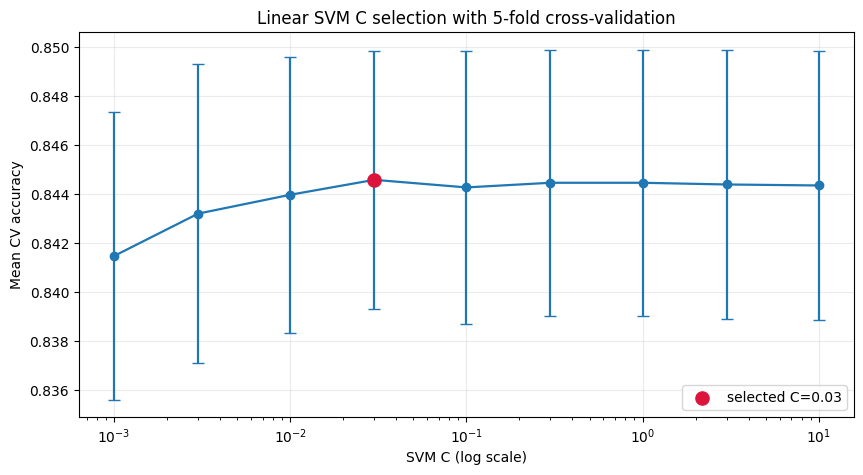

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, NUMERIC_FEATURES),
        ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LinearSVC(
                dual="auto",
                max_iter=10000,
                random_state=42,
            ),
        ),
    ]
)

C_VALUES = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
N_FOLDS = 5

cv_splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

param_grid = {
    "model__C": C_VALUES,
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_splitter,
    refit=True,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_dev, y_dev)

fold_score_columns = [f"split{fold_idx}_test_score" for fold_idx in range(N_FOLDS)]
fold_accuracy_columns = [f"fold_{fold_idx + 1}_accuracy" for fold_idx in range(N_FOLDS)]

cv_results_df = pd.DataFrame(grid_search.cv_results_)[
    [
        "param_model__C",
        *fold_score_columns,
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score",
    ]
].rename(
    columns={
        "param_model__C": "svm_C",
        **dict(zip(fold_score_columns, fold_accuracy_columns)),
        "mean_test_score": "mean_cv_accuracy",
        "std_test_score": "std_cv_accuracy",
        "mean_train_score": "mean_train_accuracy",
        "rank_test_score": "grid_rank",
    }
)

cv_results_df["svm_C"] = cv_results_df["svm_C"].astype(float)
cv_results_df["mean_cv_accuracy_rounded"] = cv_results_df["mean_cv_accuracy"].round(5)

cv_results_ranked_df = cv_results_df.sort_values(
    by=["mean_cv_accuracy_rounded", "svm_C"],
    ascending=[False, True],
).reset_index(drop=True)

selected_row = cv_results_ranked_df.iloc[0]
selected_params = {
    "model__C": float(selected_row["svm_C"]),
}
selected_fold_accuracies = [float(selected_row[column]) for column in fold_accuracy_columns]
selected_fold_accuracy_records = [
    {
        "fold": fold_idx + 1,
        "svm_C": selected_params["model__C"],
        "accuracy": selected_fold_accuracies[fold_idx],
    }
    for fold_idx in range(N_FOLDS)
]

selected_pipeline = clone(base_pipeline).set_params(**selected_params)
selected_pipeline.fit(X_dev, y_dev)

selection_summary_df = pd.DataFrame(
    [
        {
            "selection_source": "GridSearchCV raw best params",
            "params": json.dumps(grid_search.best_params_, sort_keys=True),
            "mean_cv_accuracy": round(float(grid_search.best_score_), 5),
        },
        {
            "selection_source": "Notebook tie-break selection",
            "params": json.dumps(selected_params, sort_keys=True),
            "mean_cv_accuracy": round(float(selected_row["mean_cv_accuracy"]), 5),
        },
    ]
)

c_cv_display_df = cv_results_df.sort_values("svm_C").reset_index(drop=True).copy()
c_cv_display_df["selected"] = np.where(
    c_cv_display_df["svm_C"] == selected_params["model__C"],
    "selected",
    "",
)
c_cv_display_df[fold_accuracy_columns + ["mean_cv_accuracy", "std_cv_accuracy", "mean_train_accuracy"]] = c_cv_display_df[
    fold_accuracy_columns + ["mean_cv_accuracy", "std_cv_accuracy", "mean_train_accuracy"]
].round(5)

selected_fold_accuracy_df = pd.DataFrame(selected_fold_accuracy_records)
selected_fold_accuracy_df["accuracy"] = selected_fold_accuracy_df["accuracy"].round(5)

optimal_c_summary = (
    "### Final cross-validation result\n"
    f"- SVM C: `{selected_params['model__C']}`\n"
    f"- mean CV accuracy: `{float(selected_row['mean_cv_accuracy']):.5f}`\n"
    f"- fold accuracies: `{', '.join(f'{accuracy:.5f}' for accuracy in selected_fold_accuracies)}`\n"
    "- tie-break rule: if rounded CV accuracies tie, choose the smaller `C` for stronger regularization"
)

display(
    Markdown(
        "### Accuracy by SVM C\n"
        "Each row shows one SVM `C` value. The fold columns show the accuracy from the 5 stratified folds."
    )
)
display(
    c_cv_display_df[
        [
            "svm_C",
            *fold_accuracy_columns,
            "mean_cv_accuracy",
            "std_cv_accuracy",
            "mean_train_accuracy",
            "selected",
        ]
    ]
)

display(Markdown("### Folds for the selected C"))
display(selected_fold_accuracy_df)
display(selection_summary_df)
display(Markdown(optimal_c_summary))

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    c_cv_display_df["svm_C"],
    c_cv_display_df["mean_cv_accuracy"],
    yerr=c_cv_display_df["std_cv_accuracy"],
    fmt="o-",
    capsize=4,
    linewidth=1.6,
)
ax.scatter(
    [selected_params["model__C"]],
    [float(selected_row["mean_cv_accuracy"])],
    color="crimson",
    s=90,
    label=f"selected C={selected_params['model__C']}",
    zorder=3,
)
ax.set_xscale("log")
ax.set_title("Linear SVM C selection with 5-fold cross-validation")
ax.set_xlabel("SVM C (log scale)")
ax.set_ylabel("Mean CV accuracy")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Holdout Evaluation

After choosing `C` with cross-validation, the selected SVM is evaluated on the holdout split. The holdout split was not used to choose `C`, so it gives a more honest estimate of performance on unseen labeled data.

## Metrics Reported

- **Accuracy (`accuracy`)**: overall proportion of correct predictions.
- **Error rate (`1 - accuracy`)**: overall proportion of incorrect predictions.
- **Balanced accuracy**: average recall across classes, useful when classes are imbalanced.
- **Precision for class `>50K`**: among samples predicted as `>50K`, how many were truly `>50K`.
- **Recall / sensitivity for class `>50K`**: among truly `>50K` samples, how many the model found.
- **Specificity for class `<=50K`**: among truly `<=50K` samples, how many the model kept as `<=50K`.
- **F1-score for class `>50K`**: harmonic mean of precision and recall.
- **ROC AUC**: how well the model ranks positive samples above negative samples using the SVM margin score from `decision_function`.

Because the positive class is the minority class, accuracy alone can hide important mistakes. The confusion matrix, recall/sensitivity, specificity, and F1-score are essential for interpreting performance.


,metric,value
0,accuracy,0.84880
1,error_rate,0.15120
2,balanced_accuracy,0.75871
3,precision_positive,0.73360
4,recall_positive,0.58482
5,sensitivity,0.58482
6,specificity,0.93259
7,f1_positive,0.65082
8,roc_auc,0.89723


,pred_<=50K,pred_>50K
actual_<=50K,4607,333
actual_>50K,651,917


,term,count,meaning
0,true_negatives,4607,<=50K predicted as <=50K
1,false_positives,333,<=50K incorrectly predicted as >50K
2,false_negatives,651,>50K incorrectly predicted as <=50K
3,true_positives,917,>50K predicted as >50K


,precision,recall,f1-score,support
<=50K,0.876189,0.932591,0.903510,4940.000000
>50K,0.733600,0.584821,0.650816,1568.000000
accuracy,0.848801,0.848801,0.848801,0.848801
macro avg,0.804894,0.758706,0.777163,6508.000000
weighted avg,0.841834,0.848801,0.842628,6508.000000


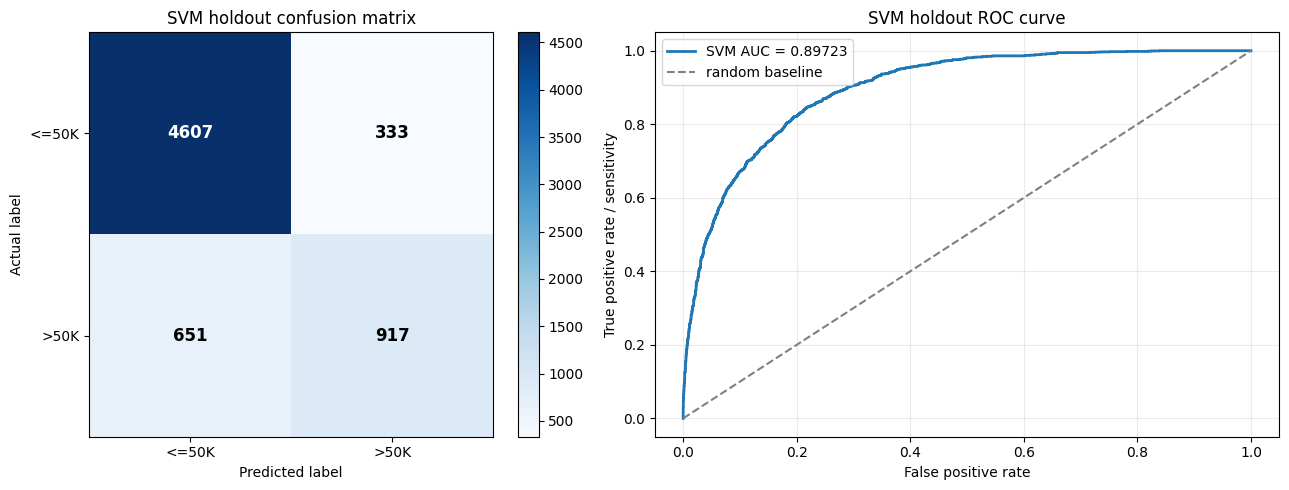

In [6]:
holdout_pred = selected_pipeline.predict(X_holdout)
holdout_scores = selected_pipeline.decision_function(X_holdout)
holdout_accuracy = float(accuracy_score(y_holdout, holdout_pred))

tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_pred, labels=[0, 1]).ravel()
sensitivity = float(tp / (tp + fn)) if (tp + fn) else 0.0
specificity = float(tn / (tn + fp)) if (tn + fp) else 0.0

holdout_metrics = {
    "accuracy": holdout_accuracy,
    "error_rate": 1 - holdout_accuracy,
    "balanced_accuracy": float(balanced_accuracy_score(y_holdout, holdout_pred)),
    "precision_positive": float(precision_score(y_holdout, holdout_pred, zero_division=0)),
    "recall_positive": float(recall_score(y_holdout, holdout_pred, zero_division=0)),
    "sensitivity": sensitivity,
    "specificity": specificity,
    "f1_positive": float(f1_score(y_holdout, holdout_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_holdout, holdout_scores)),
}

holdout_metrics_df = pd.DataFrame(
    [
        {"metric": metric_name, "value": round(metric_value, 5)}
        for metric_name, metric_value in holdout_metrics.items()
    ]
)

confusion_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=[f"actual_{NEGATIVE_LABEL}", f"actual_{POSITIVE_LABEL}"],
    columns=[f"pred_{NEGATIVE_LABEL}", f"pred_{POSITIVE_LABEL}"],
)

confusion_terms_df = pd.DataFrame(
    [
        {"term": "true_negatives", "count": int(tn), "meaning": "<=50K predicted as <=50K"},
        {"term": "false_positives", "count": int(fp), "meaning": "<=50K incorrectly predicted as >50K"},
        {"term": "false_negatives", "count": int(fn), "meaning": ">50K incorrectly predicted as <=50K"},
        {"term": "true_positives", "count": int(tp), "meaning": ">50K predicted as >50K"},
    ]
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_holdout,
        holdout_pred,
        target_names=[NEGATIVE_LABEL, POSITIVE_LABEL],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(holdout_metrics_df)
display(confusion_df)
display(confusion_terms_df)
display(classification_report_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(confusion_df.values, cmap="Blues")
axes[0].set_title("SVM holdout confusion matrix")
axes[0].set_xticks([0, 1], [NEGATIVE_LABEL, POSITIVE_LABEL])
axes[0].set_yticks([0, 1], [NEGATIVE_LABEL, POSITIVE_LABEL])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("Actual label")
for row_idx in range(2):
    for col_idx in range(2):
        axes[0].text(
            col_idx,
            row_idx,
            str(confusion_df.values[row_idx, col_idx]),
            ha="center",
            va="center",
            color="white" if confusion_df.values[row_idx, col_idx] > confusion_df.values.max() / 2 else "black",
            fontsize=12,
            weight="bold",
        )
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

fpr, tpr, roc_thresholds = roc_curve(y_holdout, holdout_scores)
axes[1].plot(fpr, tpr, label=f"SVM AUC = {holdout_metrics['roc_auc']:.5f}", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="random baseline")
axes[1].set_title("SVM holdout ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate / sensitivity")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Linear SVM Feature-Space Interpretation

A linear SVM learns one coefficient per transformed feature. Positive coefficients push the decision score toward `>50K`; negative coefficients push it toward `<=50K`.

This is different from kNN:

- kNN stores training examples and predicts from local neighbor votes;
- linear SVM learns a global hyperplane in the transformed feature space;
- kNN uses distances at prediction time, while linear SVM uses the learned coefficients and intercept;
- SVM's `C` controls regularization, while kNN's `k` controls neighborhood size.

The PCA plot below is only a 2D visualization. The actual SVM is trained on all preprocessed features, not only two PCA axes.


### Largest SVM coefficients

,direction,feature,coefficient,absolute_coefficient
0,toward >50K,relationship_Wife,0.33099,0.33099
1,toward >50K,education.num,0.29000,0.29000
2,toward >50K,marital.status_infrequent_sklearn,0.27918,0.27918
3,toward >50K,marital.status_Married-civ-spouse,0.27738,0.27738
4,toward >50K,occupation_Exec-managerial,0.27026,0.27026
5,toward >50K,native.country_Germany,0.19783,0.19783
6,toward >50K,occupation_Tech-support,0.19194,0.19194
7,toward >50K,occupation_Protective-serv,0.19034,0.19034
8,toward >50K,occupation_Prof-specialty,0.18728,0.18728
9,toward >50K,native.country_Italy,0.17447,0.17447


### Representative holdout cases near the SVM margin

,case,actual,predicted,decision_score,distance_to_margin_abs
0,Correct <=50K,<=50K,<=50K,-0.00138,0.00138
1,Correct >50K,>50K,>50K,0.00007,0.00007
2,False positive,<=50K,>50K,0.00088,0.00088
3,False negative,>50K,<=50K,-0.00244,0.00244


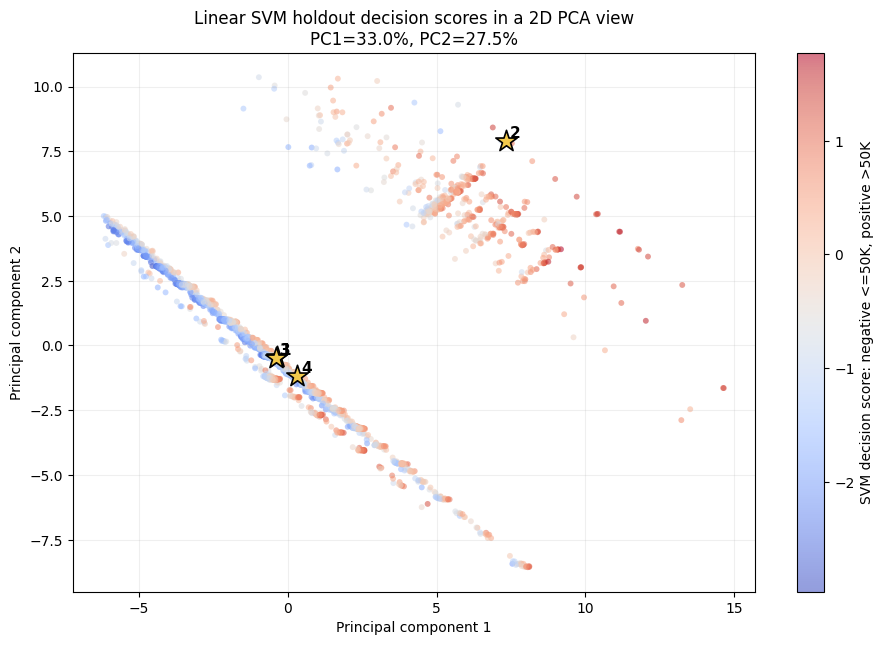

In [7]:
preprocessor = selected_pipeline.named_steps["preprocessor"]
svm_model = selected_pipeline.named_steps["model"]

X_dev_trans = preprocessor.transform(X_dev)
X_holdout_trans = preprocessor.transform(X_holdout)
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": svm_model.coef_.ravel(),
    }
)
coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

positive_coef_df = coef_df.sort_values("coefficient", ascending=False).head(12).reset_index(drop=True)
negative_coef_df = coef_df.sort_values("coefficient", ascending=True).head(12).reset_index(drop=True)

coef_display_df = pd.concat(
    [
        positive_coef_df.assign(direction=f"toward {POSITIVE_LABEL}"),
        negative_coef_df.assign(direction=f"toward {NEGATIVE_LABEL}"),
    ],
    ignore_index=True,
)
coef_display_df["coefficient"] = coef_display_df["coefficient"].round(5)
coef_display_df["absolute_coefficient"] = coef_display_df["absolute_coefficient"].round(5)

display(Markdown("### Largest SVM coefficients"))
display(coef_display_df[["direction", "feature", "coefficient", "absolute_coefficient"]])

# 2D PCA is used only for visualization of the modeled feature space.
pca_2d = PCA(n_components=2)
X_dev_vis = pca_2d.fit_transform(X_dev_trans)
X_holdout_vis = pca_2d.transform(X_holdout_trans)

holdout_scores = selected_pipeline.decision_function(X_holdout)
y_holdout_array = y_holdout.to_numpy()
holdout_pred_array = holdout_pred

case_definitions = [
    ("Correct <=50K", (y_holdout_array == 0) & (holdout_pred_array == 0)),
    ("Correct >50K", (y_holdout_array == 1) & (holdout_pred_array == 1)),
    ("False positive", (y_holdout_array == 0) & (holdout_pred_array == 1)),
    ("False negative", (y_holdout_array == 1) & (holdout_pred_array == 0)),
]

selected_cases = []
used_indices = set()

def pick_closest_to_margin(mask):
    candidate_idx = np.where(mask)[0]
    candidate_idx = np.array([idx for idx in candidate_idx if idx not in used_indices])
    if len(candidate_idx) == 0:
        return None
    chosen = candidate_idx[np.argmin(np.abs(holdout_scores[candidate_idx]))]
    used_indices.add(int(chosen))
    return int(chosen)

for label, mask in case_definitions:
    idx = pick_closest_to_margin(mask)
    if idx is not None:
        selected_cases.append((label, idx))

if len(selected_cases) < 4:
    remaining = np.array([idx for idx in range(len(X_holdout_vis)) if idx not in used_indices])
    remaining = remaining[np.argsort(np.abs(holdout_scores[remaining]))]
    for idx in remaining[: 4 - len(selected_cases)]:
        used_indices.add(int(idx))
        selected_cases.append(("Closest holdout sample to SVM margin", int(idx)))

case_summary_df = pd.DataFrame(
    [
        {
            "case": case_label,
            "actual": POSITIVE_LABEL if y_holdout_array[idx] == 1 else NEGATIVE_LABEL,
            "predicted": POSITIVE_LABEL if holdout_pred_array[idx] == 1 else NEGATIVE_LABEL,
            "decision_score": round(float(holdout_scores[idx]), 5),
            "distance_to_margin_abs": round(float(abs(holdout_scores[idx])), 5),
        }
        for case_label, idx in selected_cases
    ]
)

display(Markdown("### Representative holdout cases near the SVM margin"))
display(case_summary_df)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    X_holdout_vis[:, 0],
    X_holdout_vis[:, 1],
    c=holdout_scores,
    cmap="coolwarm",
    s=18,
    alpha=0.55,
    edgecolor="none",
)

for case_number, (case_label, idx) in enumerate(selected_cases, start=1):
    ax.scatter(
        X_holdout_vis[idx, 0],
        X_holdout_vis[idx, 1],
        s=260,
        marker="*",
        c="#f2c94c",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )
    ax.text(
        X_holdout_vis[idx, 0] + 0.12,
        X_holdout_vis[idx, 1] + 0.12,
        str(case_number),
        fontsize=11,
        weight="bold",
        color="black",
    )

ax.set_title(
    "Linear SVM holdout decision scores in a 2D PCA view\n"
    f"PC1={pca_2d.explained_variance_ratio_[0]:.1%}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.1%}"
)
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.grid(alpha=0.2)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("SVM decision score: negative <=50K, positive >50K")
plt.show()


## Interpretable Plots With Real Variables

PCA helps visualize the transformed feature space, but its axes do not map directly to a single original feature. The next visualizations use real dataset variables instead.

These plots do not replace model metrics, but they help explain broad patterns in the data, such as differences by sex, weekly hours, and income group. They are kept consistent with the kNN notebook so that the reading flow stays familiar.


,sex,count,mean,median,std
0,Female,10762,36.42,40.0,11.81
1,Male,21774,42.43,40.0,12.12


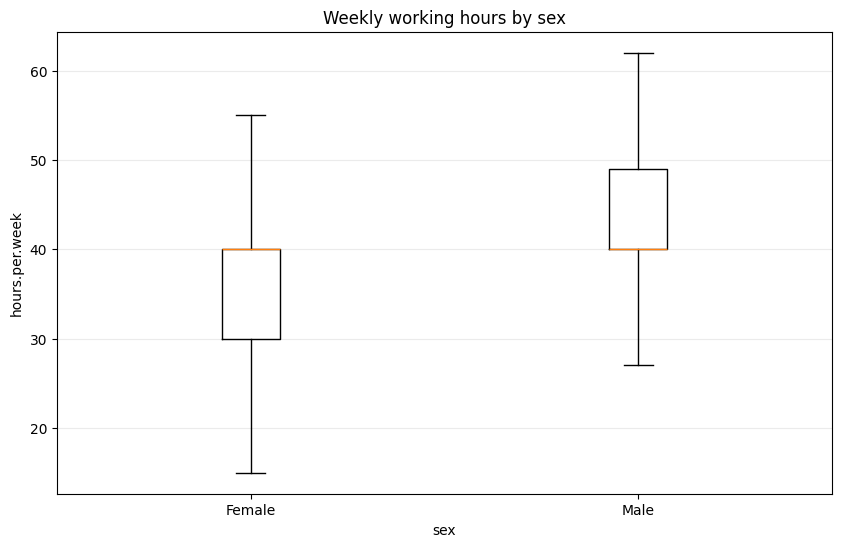

In [8]:
# sex vs hours.per.week

plot_df = train_prepared[["sex", "hours.per.week"]].copy()
sex_order = sorted(plot_df["sex"].dropna().unique().tolist())

summary_df = (
    plot_df.groupby("sex")["hours.per.week"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .reset_index()
)

display(summary_df)

fig, ax = plt.subplots(figsize=(10, 6))

hours_by_sex = [
    plot_df.loc[plot_df["sex"] == sex_value, "hours.per.week"].to_numpy()
    for sex_value in sex_order
]

ax.boxplot(hours_by_sex, tick_labels=sex_order, showfliers=False)
ax.set_title("Weekly working hours by sex")
ax.set_xlabel("sex")
ax.set_ylabel("hours.per.week")
ax.grid(axis="y", alpha=0.25)
plt.show()


income,sex,<=50K,>50K
0,Female,9583,1179
1,Male,15114,6660


income,sex,<=50K,>50K
0,Female,0.8904,0.1096
1,Male,0.6941,0.3059


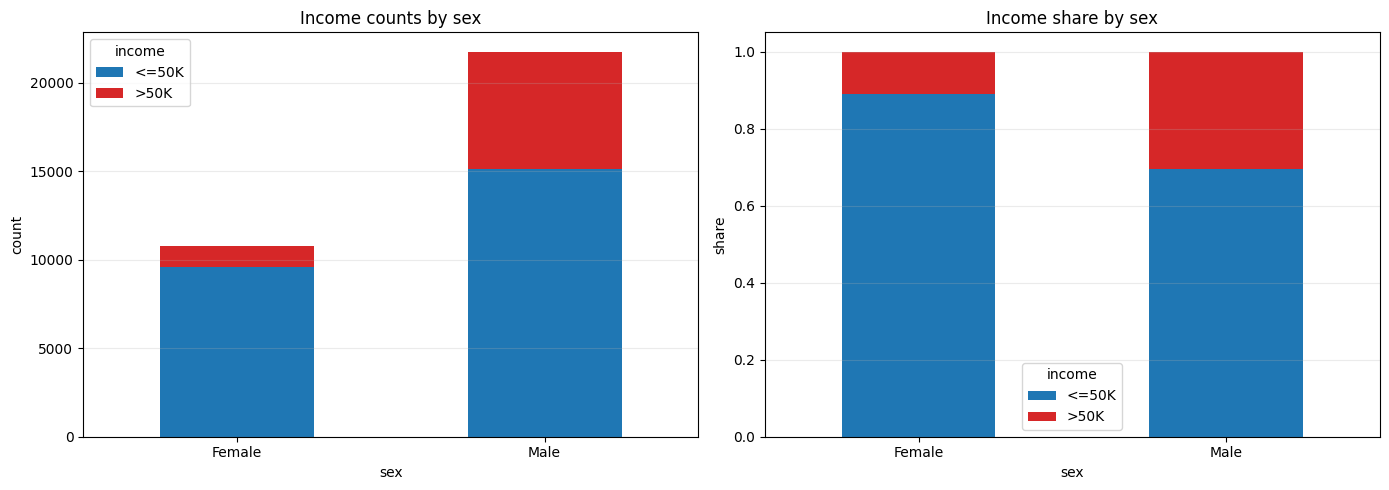

In [9]:
# sex vs income

plot_df = train_prepared[["sex", "income"]].copy()
sex_order = sorted(plot_df["sex"].dropna().unique().tolist())
income_order = ["<=50K", ">50K"]

count_df = (
    pd.crosstab(plot_df["sex"], plot_df["income"])
    .reindex(index=sex_order, columns=income_order)
    .fillna(0)
    .astype(int)
)

share_df = count_df.div(count_df.sum(axis=1), axis=0)

display(count_df.reset_index())
display(share_df.round(4).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

count_df.plot(kind="bar", stacked=True, ax=axes[0], color=["#1f77b4", "#d62728"])
axes[0].set_title("Income counts by sex")
axes[0].set_xlabel("sex")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.25)

share_df.plot(kind="bar", stacked=True, ax=axes[1], color=["#1f77b4", "#d62728"])
axes[1].set_title("Income share by sex")
axes[1].set_xlabel("sex")
axes[1].set_ylabel("share")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## Fair Comparison With kNN

The comparison below uses the kNN holdout metrics saved by the previous notebook and the SVM holdout metrics from this notebook.

This is a fair local comparison because both models use:

- the same prepared data;
- the same selected feature columns;
- the same stratified 80/20 development/holdout split;
- cross-validation only on the development set;
- final local evaluation only on the holdout set.

The competition test set is not used in this comparison because it has no local ground-truth labels.


In [10]:
def metrics_from_knn_payload(knn_payload):
    metrics = dict(knn_payload["holdout_metrics"])
    confusion_payload = knn_payload["holdout_confusion_matrix"]
    knn_tn = int(confusion_payload[f"pred_{NEGATIVE_LABEL}"][f"actual_{NEGATIVE_LABEL}"])
    knn_fp = int(confusion_payload[f"pred_{POSITIVE_LABEL}"][f"actual_{NEGATIVE_LABEL}"])
    knn_fn = int(confusion_payload[f"pred_{NEGATIVE_LABEL}"][f"actual_{POSITIVE_LABEL}"])
    knn_tp = int(confusion_payload[f"pred_{POSITIVE_LABEL}"][f"actual_{POSITIVE_LABEL}"])
    metrics["sensitivity"] = float(knn_tp / (knn_tp + knn_fn)) if (knn_tp + knn_fn) else 0.0
    metrics["specificity"] = float(knn_tn / (knn_tn + knn_fp)) if (knn_tn + knn_fp) else 0.0
    return metrics

comparison_metric_order = [
    "accuracy",
    "error_rate",
    "balanced_accuracy",
    "precision_positive",
    "recall_positive",
    "sensitivity",
    "specificity",
    "f1_positive",
    "roc_auc",
]

knn_metrics_path = SUBMISSIONS_DIR / "knn_holdout_metrics.json"
comparison_df = None

if knn_metrics_path.exists():
    knn_payload = json.loads(knn_metrics_path.read_text())
    knn_metrics = metrics_from_knn_payload(knn_payload)

    comparison_df = pd.DataFrame(
        [
            {
                "model": "kNN",
                "selection_hyperparameter": "k, weights, p",
                "selected_value": json.dumps(knn_payload["selected_params"], sort_keys=True),
                **{metric: knn_metrics.get(metric, np.nan) for metric in comparison_metric_order},
            },
            {
                "model": "Linear SVM",
                "selection_hyperparameter": "C",
                "selected_value": json.dumps(selected_params, sort_keys=True),
                **{metric: holdout_metrics.get(metric, np.nan) for metric in comparison_metric_order},
            },
        ]
    )

    comparison_display_df = comparison_df.copy()
    comparison_display_df[comparison_metric_order] = comparison_display_df[comparison_metric_order].round(5)
    display(comparison_display_df)

    metric_delta_df = pd.DataFrame(
        [
            {
                "metric": metric,
                "svm_minus_knn": round(
                    float(comparison_df.loc[comparison_df["model"] == "Linear SVM", metric].iloc[0])
                    - float(comparison_df.loc[comparison_df["model"] == "kNN", metric].iloc[0]),
                    5,
                ),
            }
            for metric in comparison_metric_order
        ]
    )
    display(metric_delta_df)
else:
    display(Markdown(f"Could not find `{knn_metrics_path.relative_to(PROJECT_ROOT)}`. Run the kNN notebook first to build the comparison table."))


,model,selection_hyperparameter,selected_value,accuracy,error_rate,balanced_accuracy,precision_positive,recall_positive,sensitivity,specificity,f1_positive,roc_auc
0,kNN,"k, weights, p","{""model__n_neighbors"": 61, ""model__p"": 1, ""model__weights"": ""uniform""}",0.84819,0.15181,0.77354,0.70803,0.62946,0.62946,0.91761,0.66644,0.90215
1,Linear SVM,C,"{""model__C"": 0.03}",0.84880,0.15120,0.75871,0.73360,0.58482,0.58482,0.93259,0.65082,0.89723


,metric,svm_minus_knn
0,accuracy,0.00061
1,error_rate,-0.00061
2,balanced_accuracy,-0.01483
3,precision_positive,0.02557
4,recall_positive,-0.04464
5,sensitivity,-0.04464
6,specificity,0.01498
7,f1_positive,-0.01563
8,roc_auc,-0.00492


## Final Training and Submission Generation

After holdout evaluation, the selected SVM pipeline is fit again using **the full labeled training set**.

This is done because, once `C` has been selected and evaluated, we want to use all available labeled examples to generate predictions for the competition test set.

Important notes:

- The final test set does not include `income`, so local accuracy cannot be computed on it.
- The reliable metrics in this notebook come from the holdout split.
- `svm_submission.csv` contains only the final predictions for submission.

Saved artifacts:

- `submissions/svm_best_params.json`: selected hyperparameter and fold accuracies.
- `submissions/svm_holdout_metrics.json`: holdout metrics and confusion matrix.
- `submissions/svm_submission.csv`: final predictions for the test set.
- `submissions/knn_vs_svm_holdout_comparison.csv`: holdout comparison when kNN metrics are available.


In [11]:
final_pipeline = clone(base_pipeline).set_params(**selected_params)
final_pipeline.fit(X_train_full, y_binary)

test_pred_binary = final_pipeline.predict(X_test_final)
test_pred_labels = np.where(test_pred_binary == 1, POSITIVE_LABEL, NEGATIVE_LABEL)

submission_df = pd.DataFrame(
    {
        ID_COL: test_prepared[ID_COL].values,
        TARGET_COL: test_pred_labels,
    }
)

assert submission_df.columns.tolist() == [ID_COL, TARGET_COL], "Submission columns must be Id and income."
assert len(submission_df) == len(test_prepared), "Submission row count must match test_prepared.csv."
assert set(submission_df[TARGET_COL].unique()).issubset({NEGATIVE_LABEL, POSITIVE_LABEL}), "Submission labels must be <=50K or >50K."

submission_path = SUBMISSIONS_DIR / "svm_submission.csv"
metrics_path = SUBMISSIONS_DIR / "svm_holdout_metrics.json"
best_params_path = SUBMISSIONS_DIR / "svm_best_params.json"
comparison_path = SUBMISSIONS_DIR / "knn_vs_svm_holdout_comparison.csv"

holdout_metrics_payload = {
    "selected_params": selected_params,
    "best_mean_cv_accuracy": float(selected_row["mean_cv_accuracy"]),
    "holdout_metrics": holdout_metrics,
    "holdout_confusion_matrix": confusion_df.to_dict(),
    "holdout_confusion_terms": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    },
    "evaluation_protocol": {
        "development_split": "80% of labeled train_prepared.csv, stratified, used for CV/model selection",
        "holdout_split": "20% of labeled train_prepared.csv, stratified, used only for final local evaluation",
        "competition_test": "test_prepared.csv, no local labels, used only for final submission predictions",
        "cv": f"{N_FOLDS}-fold StratifiedKFold with shuffle=True and random_state=42",
        "selection_metric": "accuracy",
    },
}

best_params_payload = {
    "grid_search_best_params": grid_search.best_params_,
    "tie_break_selected_params": selected_params,
    "tie_break_changed_selection": bool(grid_search.best_params_ != selected_params),
    "tie_break_rule": "If rounded mean CV accuracies tie, choose the smaller C for stronger regularization.",
    "selected_mean_cv_accuracy": float(selected_row["mean_cv_accuracy"]),
    "selected_mean_cv_accuracy_rounded": float(selected_row["mean_cv_accuracy_rounded"]),
    "selected_std_cv_accuracy": float(selected_row["std_cv_accuracy"]),
    "selected_fold_accuracies": selected_fold_accuracies,
    "selected_fold_accuracy_by_fold": selected_fold_accuracy_records,
    "tested_C_values": C_VALUES,
}

submission_df.to_csv(submission_path, index=False)
metrics_path.write_text(json.dumps(holdout_metrics_payload, indent=2))
best_params_path.write_text(json.dumps(best_params_payload, indent=2))

saved_artifacts = [
    {"artifact": "submission", "path": str(submission_path.relative_to(PROJECT_ROOT))},
    {"artifact": "holdout_metrics", "path": str(metrics_path.relative_to(PROJECT_ROOT))},
    {"artifact": "best_params", "path": str(best_params_path.relative_to(PROJECT_ROOT))},
]

if comparison_df is not None:
    comparison_df.to_csv(comparison_path, index=False)
    saved_artifacts.append({"artifact": "knn_vs_svm_holdout_comparison", "path": str(comparison_path.relative_to(PROJECT_ROOT))})

saved_artifacts_df = pd.DataFrame(saved_artifacts)

display(saved_artifacts_df)
display(submission_df.head())
display(Markdown(f"Submission saved to `{submission_path.relative_to(PROJECT_ROOT)}`."))


,artifact,path
0,submission,submissions/svm_submission.csv
1,holdout_metrics,submissions/svm_holdout_metrics.json
2,best_params,submissions/svm_best_params.json
3,knn_vs_svm_holdout_comparison,submissions/knn_vs_svm_holdout_comparison.csv


,Id,income
0,0,<=50K
1,1,>50K
2,2,<=50K
3,3,<=50K
4,4,>50K


Submission saved to `submissions/svm_submission.csv`.